In [1]:
"""
=============================================================================
CP-DYNAMIC-METRO-SP — São Paulo (Metrô + CPTM)
Checkpoint 2 — Dynamic Programming — FIAP
=============================================================================

OBJETIVO
--------
Modelar a rede de metrô e CPTM de São Paulo como um grafo ponderado e
encontrar o menor e o maior caminho entre Tucuruvi e Capão Redondo,
aplicando programação dinâmica (memoização via lru_cache) e comparando
com a versão sem cache.

O custo de cada trecho varia dinamicamente conforme:
  - O fator de horário (pico, normal, noturno)
  - O peso da linha (linhas modernas são mais rápidas)
  - A penalidade por troca de linha em estações de integração

ALGORITMOS IMPLEMENTADOS
-------------------------
  1. Menor caminho COM memoização  — DFS + lru_cache
  2. Menor caminho SEM memoização  — DFS puro (sem cache)
  3. Maior caminho                 — Backtracking exaustivo (sem cache)

COMPLEXIDADE
------------
  - DFS sem memo : O(n!)   — explora todas as permutações de nós
  - DFS com memo : O(n × 2^n) — limitado pelos estados (nó, visitados)
  - Maior caminho: O(n!)   — NP-difícil (longest simple path)
=============================================================================
"""

# ── Imports ──────────────────────────────────────────────────────────────────
import time           # medição de tempo de execução (perf_counter)
import tracemalloc    # medição de uso de memória heap
import functools      # lru_cache para memoização
import math           # math.isinf para verificar ausência de caminho

import matplotlib.pyplot as plt   # geração de gráficos comparativos
import matplotlib.patches as mpatches

# =============================================================================
# MODELAGEM DO GRAFO — SÃO PAULO (METRÔ + CPTM)
# =============================================================================
# Representação: dicionário de listas de adjacência.
# Grafo NÃO-DIRIGIDO (bidirecional): cada aresta aparece nos dois sentidos,
# pois os trens operam em ambas as direções.
#
# Cada aresta é um dicionário com:
#   "destino" : nome da estação vizinha (str)
#   "linha"   : identificador da linha (str) — azul, verde, amarela, lilás, esmeralda
#   "tempo"   : peso base em minutos (int/float)
#
# Linhas presentes:
#   azul      — Linha 1 (Tucuruvi ↔ Jabaquara)
#   verde     — Linha 2 (Vila Madalena ↔ Chácara Klabin)
#   amarela   — Linha 4 (Luz ↔ Vila Sônia)
#   lilás     — Linha 5 (Capão Redondo ↔ Chácara Klabin / Santa Cruz)
#   esmeralda — CPTM (Pinheiros ↔ Santo Amaro) — mais lenta
# =============================================================================

grafo = {

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA 1 — AZUL  (Tucuruvi → Jabaquara)
    # ─────────────────────────────────────────────────────────────────────────
    "Tucuruvi": [
        {"destino": "Parada Inglesa", "linha": "azul", "tempo": 2}
    ],
    "Parada Inglesa": [
        {"destino": "Tucuruvi",        "linha": "azul", "tempo": 2},
        {"destino": "Jardim Sao Paulo","linha": "azul", "tempo": 2}
    ],
    "Jardim Sao Paulo": [
        {"destino": "Parada Inglesa",  "linha": "azul", "tempo": 2},
        {"destino": "Santana",         "linha": "azul", "tempo": 2}
    ],
    "Santana": [
        {"destino": "Jardim Sao Paulo","linha": "azul", "tempo": 2},
        {"destino": "Carandiru",       "linha": "azul", "tempo": 2}
    ],
    "Carandiru": [
        {"destino": "Santana",          "linha": "azul", "tempo": 2},
        {"destino": "Portuguesa-Tiete", "linha": "azul", "tempo": 2}
    ],
    "Portuguesa-Tiete": [
        {"destino": "Carandiru",  "linha": "azul", "tempo": 2},
        {"destino": "Armenia",    "linha": "azul", "tempo": 2}
    ],
    "Armenia": [
        {"destino": "Portuguesa-Tiete", "linha": "azul", "tempo": 2},
        {"destino": "Tiradentes",       "linha": "azul", "tempo": 2}
    ],
    "Tiradentes": [
        {"destino": "Armenia", "linha": "azul", "tempo": 2},
        {"destino": "Luz",     "linha": "azul", "tempo": 2}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB LUZ — integração Azul ↔ Amarela
    # Penalidade reduzida pois é uma das maiores estações de integração da SP
    # ─────────────────────────────────────────────────────────────────────────
    "Luz": [
        {"destino": "Tiradentes", "linha": "azul",    "tempo": 2},
        {"destino": "Sao Bento",  "linha": "azul",    "tempo": 2},
        {"destino": "Republica",  "linha": "amarela",  "tempo": 3}  # integração
    ],
    "Sao Bento": [
        {"destino": "Luz", "linha": "azul", "tempo": 2},
        {"destino": "Se",  "linha": "azul", "tempo": 2}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB SÉ — nó central da Linha Azul
    # ─────────────────────────────────────────────────────────────────────────
    "Se": [
        {"destino": "Sao Bento",  "linha": "azul", "tempo": 2},
        {"destino": "Liberdade",  "linha": "azul", "tempo": 2}
    ],
    "Liberdade": [
        {"destino": "Se",          "linha": "azul", "tempo": 2},
        {"destino": "Sao Joaquim", "linha": "azul", "tempo": 2}
    ],
    "Sao Joaquim": [
        {"destino": "Liberdade", "linha": "azul", "tempo": 2},
        {"destino": "Vergueiro", "linha": "azul", "tempo": 2}
    ],
    "Vergueiro": [
        {"destino": "Sao Joaquim", "linha": "azul", "tempo": 2},
        {"destino": "Paraiso",     "linha": "azul", "tempo": 2}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB PARAÍSO — integração Azul ↔ Verde
    # ─────────────────────────────────────────────────────────────────────────
    "Paraiso": [
        {"destino": "Vergueiro",  "linha": "azul",  "tempo": 2},
        {"destino": "Ana Rosa",   "linha": "azul",  "tempo": 2},
        {"destino": "Brigadeiro", "linha": "verde",  "tempo": 2}  # integração
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB ANA ROSA — integração Azul ↔ Verde
    # ─────────────────────────────────────────────────────────────────────────
    "Ana Rosa": [
        {"destino": "Paraiso",         "linha": "azul",  "tempo": 2},
        {"destino": "Vila Mariana",     "linha": "azul",  "tempo": 2},
        {"destino": "Chacara Klabin",   "linha": "verde",  "tempo": 3}  # integração
    ],
    "Vila Mariana": [
        {"destino": "Ana Rosa",    "linha": "azul", "tempo": 2},
        {"destino": "Santa Cruz",  "linha": "azul", "tempo": 2}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB SANTA CRUZ — integração Azul ↔ Lilás
    # ─────────────────────────────────────────────────────────────────────────
    "Santa Cruz": [
        {"destino": "Vila Mariana",    "linha": "azul",  "tempo": 2},
        {"destino": "Praca da Arvore", "linha": "azul",  "tempo": 2},
        {"destino": "Santo Amaro",     "linha": "lilas",  "tempo": 8},  # integração longa
        {"destino": "Chacara Klabin",  "linha": "lilas",  "tempo": 3}   # integração
    ],
    "Praca da Arvore": [
        {"destino": "Santa Cruz", "linha": "azul", "tempo": 2},
        {"destino": "Saude",      "linha": "azul", "tempo": 2}
    ],
    "Saude": [
        {"destino": "Praca da Arvore", "linha": "azul", "tempo": 2},
        {"destino": "Sao Judas",       "linha": "azul", "tempo": 2}
    ],
    "Sao Judas": [
        {"destino": "Saude",      "linha": "azul", "tempo": 2},
        {"destino": "Conceicao",  "linha": "azul", "tempo": 2}
    ],
    "Conceicao": [
        {"destino": "Sao Judas",  "linha": "azul", "tempo": 2},
        {"destino": "Jabaquara",  "linha": "azul", "tempo": 2}
    ],
    "Jabaquara": [
        {"destino": "Conceicao", "linha": "azul", "tempo": 2}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA 2 — VERDE  (Brigadeiro → Vila Madalena / Chácara Klabin)
    # ─────────────────────────────────────────────────────────────────────────
    "Brigadeiro": [
        {"destino": "Paraiso",      "linha": "verde", "tempo": 2},
        {"destino": "Trianon-Masp", "linha": "verde", "tempo": 2}
    ],
    "Trianon-Masp": [
        {"destino": "Brigadeiro",  "linha": "verde", "tempo": 2},
        {"destino": "Consolacao",  "linha": "verde", "tempo": 2}
    ],
    "Consolacao": [
        {"destino": "Trianon-Masp", "linha": "verde", "tempo": 2},
        {"destino": "Clinicas",     "linha": "verde", "tempo": 2}
    ],
    "Clinicas": [
        {"destino": "Consolacao", "linha": "verde", "tempo": 2},
        {"destino": "Sumare",     "linha": "verde", "tempo": 2}
    ],
    "Sumare": [
        {"destino": "Clinicas",      "linha": "verde", "tempo": 2},
        {"destino": "Vila Madalena", "linha": "verde", "tempo": 3}
    ],
    "Vila Madalena": [
        {"destino": "Sumare", "linha": "verde", "tempo": 3}
    ],
    "Chacara Klabin": [
        {"destino": "Ana Rosa",    "linha": "verde",  "tempo": 3},
        {"destino": "Santa Cruz",  "linha": "lilas",  "tempo": 3}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA 4 — AMARELA  (Luz → Vila Sônia)
    # Linha mais moderna: peso 0,9 (mais rápida proporcionalmente)
    # ─────────────────────────────────────────────────────────────────────────
    "Republica": [
        {"destino": "Luz",      "linha": "amarela", "tempo": 3},
        {"destino": "Paulista", "linha": "amarela", "tempo": 3}
    ],
    "Paulista": [
        {"destino": "Republica",  "linha": "amarela", "tempo": 3},
        {"destino": "Pinheiros",  "linha": "amarela", "tempo": 5}
    ],
    "Pinheiros": [
        {"destino": "Paulista",    "linha": "amarela",   "tempo": 5},
        {"destino": "Vila Sonia",  "linha": "amarela",   "tempo": 5},
        {"destino": "Santo Amaro", "linha": "esmeralda", "tempo": 10}  # CPTM
    ],
    "Vila Sonia": [
        {"destino": "Pinheiros", "linha": "amarela", "tempo": 5}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA 5 — LILÁS  (Capão Redondo → Santa Cruz / Chácara Klabin)
    # ─────────────────────────────────────────────────────────────────────────
    "Santo Amaro": [
        {"destino": "Santa Cruz",  "linha": "lilas",     "tempo": 8},
        {"destino": "Campo Limpo", "linha": "lilas",     "tempo": 5},
        {"destino": "Pinheiros",   "linha": "esmeralda", "tempo": 10}  # CPTM
    ],
    "Campo Limpo": [
        {"destino": "Santo Amaro",   "linha": "lilas", "tempo": 5},
        {"destino": "Capao Redondo", "linha": "lilas", "tempo": 4}
    ],
    "Capao Redondo": [
        {"destino": "Campo Limpo", "linha": "lilas", "tempo": 4}
    ]
}

In [2]:
# =============================================================================
# CONFIGURAÇÕES DE CUSTO
# =============================================================================

# Fator de horário — multiplicador aplicado ao tempo base de cada aresta.
# Simula o efeito de lotação e atrasos nos horários de pico.
def fator_horario(hora: int) -> float:
    """
    Retorna o multiplicador de custo baseado no horário do dia.

    Parâmetros
    ----------
    hora : int — hora do dia (0–23)

    Retorna
    -------
    float — multiplicador a ser aplicado sobre o tempo base da aresta

    Tabela de fatores:
      05h–07h → 0,6  (bônus: metrô vazio, embarque rápido)
      07h–09h → 1,5  (pico da manhã: volume alto)
      09h–17h → 1,0  (horário normal: sem penalidade)
      17h–20h → 2,0  (pico da tarde: máxima lotação)
      demais  → 1,2  (noturno: fluxo irregular)
    """
    if 5 <= hora < 7:
        return 0.6    # bônus madrugada/manhã cedo
    elif 7 <= hora < 9:
        return 1.5    # pico manhã
    elif 9 <= hora < 17:
        return 1.0    # horário comercial normal
    elif 17 <= hora < 20:
        return 2.0    # pico tarde — máxima penalidade
    else:
        return 1.2    # noturno

# Peso por linha — reflete a velocidade comercial média de cada linha.
# Valores < 1,0 indicam linhas mais rápidas (tecnologia mais moderna).
# Valores > 1,0 indicam linhas mais lentas (CPTM, infraestrutura antiga).
PESO_LINHA = {
    "azul":      1.0,   # Linha 1 — padrão
    "verde":     1.0,   # Linha 2 — padrão
    "amarela":   0.9,   # Linha 4 — mais moderna e rápida
    "lilas":     0.95,  # Linha 5 — eficiente
    "esmeralda": 1.2    # CPTM    — mais lenta
}

In [3]:
def penalidade_troca(linha_atual: str, nova_linha: str, estacao: str) -> int:
    """
    Calcula a penalidade de tempo (minutos) por trocar de linha em uma estação.

    Lógica
    ------
    - Mesma linha → sem penalidade (0 min)
    - Estação HUB (bem estruturada) → 2 min
    - Estação comum → 6 min

    Estações HUB definidas: Sé, Luz, Paraíso, Pinheiros, Santa Cruz.
    Essas estações possuem integração física direta entre plataformas,
    reduzindo o tempo de transferência.

    Parâmetros
    ----------
    linha_atual : str — linha em que o passageiro está
    nova_linha  : str — linha para a qual irá trocar
    estacao     : str — nome da estação onde ocorre a troca

    Retorna
    -------
    int — penalidade em minutos
    """
    if linha_atual is None or linha_atual == nova_linha:
        return 0

    # Estações com infraestrutura de integração melhorada
    hubs = {"Se", "Luz", "Paraiso", "Pinheiros", "Santa Cruz"}

    return 2 if estacao in hubs else 6

In [4]:
# =============================================================================
# ALGORITMO 1 — MENOR CAMINHO COM MEMOIZAÇÃO (lru_cache)
# =============================================================================
# Abordagem: DFS recursivo com poda de nós visitados + cache de resultados.
#
# Estado cacheado: (origem, destino, hora, linha_atual, visitados)
#   - "visitados" é um frozenset (imutável, hashável) — permite uso como chave
#
# Complexidade: O(n × 2^n) estados possíveis no pior caso.
# Na prática, o grafo esparso limita severamente as combinações reais.
# =============================================================================

@functools.lru_cache(maxsize=None)
def menor_custo_com_memo(
    origem: str,
    destino: str,
    hora: int,
    linha_atual: str = None,
    visitados: frozenset = frozenset()
):
    """
    Encontra o menor custo e caminho entre duas estações usando DFS memoizado.

    O cache armazena resultados para (origem, destino, hora, linha_atual, visitados),
    evitando recomputar subproblemas já resolvidos.

    ATENÇÃO: o conjunto `visitados` na chave quase sempre cria estados únicos
    (cada caminho percorrido gera um frozenset diferente), o que reduz os
    cache hits em grafos pequenos — ver análise de desempenho ao final.

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
      - custo_total = inf  se não existe caminho
      - caminho = lista de estações do percurso (inclui origem e destino)
    """
    # Caso base: chegamos ao destino — custo zero, caminho trivial
    if origem == destino:
        return (0, [origem])

    melhor = (float('inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho  = aresta["destino"]
        linha    = aresta["linha"]
        tempo    = aresta["tempo"]

        # Evita ciclos: não revisitar nós já no caminho atual
        if vizinho in visitados:
            continue

        # Custo da aresta = tempo_base × peso_linha × fator_horario + troca
        tempo_ajustado = tempo * PESO_LINHA.get(linha, 1.0)
        custo_extra    = tempo_ajustado * fator_horario(hora)
        custo_extra   += penalidade_troca(linha_atual, linha, origem)

        # Chamada recursiva memoizada para o vizinho
        custo_rec, caminho = menor_custo_com_memo(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}   # frozenset imutável — cria nova instância
        )

        if custo_rec == float('inf'):
            continue  # sem caminho por esse vizinho

        custo_total = custo_extra + custo_rec

        if custo_total < melhor[0]:
            melhor = (custo_total, [origem] + caminho)

    return melhor

In [5]:
# =============================================================================
# ALGORITMO 2 — MENOR CAMINHO SEM MEMOIZAÇÃO (DFS puro)
# =============================================================================
# Idêntico ao algoritmo anterior, mas sem @lru_cache.
# Serve como baseline para comparar desempenho.
#
# Complexidade: O(n!) no pior caso — reexplora os mesmos subproblemas.
# Para grafos pequenos, pode ser mais rápido que a versão com cache
# devido ao overhead de hashing dos frozensets.
# =============================================================================

def menor_custo_sem_memo(
    origem: str,
    destino: str,
    hora: int,
    linha_atual: str = None,
    visitados: frozenset = frozenset()
):
    """
    Encontra o menor custo e caminho entre duas estações usando DFS puro (sem cache).

    Sem memoização: cada subárvore é explorada completamente mesmo que
    já tenha sido computada antes. Para grafos pequenos, o overhead do
    lru_cache supera o ganho de evitar recomputações.

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
    """
    if origem == destino:
        return (0, [origem])

    melhor = (float('inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho  = aresta["destino"]
        linha    = aresta["linha"]
        tempo    = aresta["tempo"]

        if vizinho in visitados:
            continue

        tempo_ajustado = tempo * PESO_LINHA.get(linha, 1.0)
        custo_extra    = tempo_ajustado * fator_horario(hora)
        custo_extra   += penalidade_troca(linha_atual, linha, origem)

        custo_rec, caminho = menor_custo_sem_memo(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}
        )

        if custo_rec == float('inf'):
            continue

        custo_total = custo_extra + custo_rec

        if custo_total < melhor[0]:
            melhor = (custo_total, [origem] + caminho)

    return melhor

In [6]:
# =============================================================================
# ALGORITMO 3 — MAIOR CAMINHO (Backtracking exaustivo)
# =============================================================================
# Busca exaustiva por backtracking: explora todos os caminhos simples
# (sem repetição de nós) e retorna o de maior custo total.
#
# Aplicação prática: identificar o pior caso de rota — útil para
# planejamento de capacidade e análise de gargalos.
#
# Complexidade: O(n!) — NP-difícil (Longest Simple Path em grafos gerais).
# Viável apenas para grafos pequenos (< ~30 nós na prática).
# =============================================================================

def maior_caminho(
    origem: str,
    destino: str,
    hora: int,
    linha_atual: str = None,
    visitados: set = None
):
    """
    Encontra o maior custo e caminho entre duas estações por backtracking exaustivo.

    Utiliza um set mutável (não hashável) para visitados — portanto não pode
    ser memoizado. A cada chamada, o estado é restaurado pelo backtracking
    implícito na operação `visitados | {origem}` (cria novo set).

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
      - custo_total = -inf se não existe caminho
    """
    if visitados is None:
        visitados = set()

    if origem == destino:
        return (0, [origem])

    maior = (float('-inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho  = aresta["destino"]
        linha    = aresta["linha"]
        tempo    = aresta["tempo"]

        if vizinho in visitados:
            continue

        tempo_ajustado = tempo * PESO_LINHA.get(linha, 1.0)
        custo_extra    = tempo_ajustado * fator_horario(hora)
        custo_extra   += penalidade_troca(linha_atual, linha, origem)

        custo_rec, caminho = maior_caminho(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}
        )

        if custo_rec == float('-inf'):
            continue

        custo_total = custo_extra + custo_rec

        if custo_total > maior[0]:
            maior = (custo_total, [origem] + caminho)

    return maior

In [7]:
# =============================================================================
# UTILITÁRIO — FORMATAÇÃO DE TEMPO
# =============================================================================

def formatar_tempo(minutos: float) -> str:
    """
    Converte minutos (float) em string legível "Xh Ymin".

    Parâmetros
    ----------
    minutos : float — tempo em minutos (pode ser inf)

    Retorna
    -------
    str — ex.: "1h 42min" ou "38 min" ou "Sem caminho"
    """
    if math.isinf(minutos):
        return "Sem caminho"
    minutos = int(minutos)
    h, m = divmod(minutos, 60)
    return f"{h}h {m}min" if h > 0 else f"{m} min"

In [8]:
# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

# Estações de origem e destino fixas para este cenário
origem  = "Tucuruvi"
destino = "Capao Redondo"

hora = int(input("Digite a hora (0-23): "))

# ── Medição COM memoização ────────────────────────────────────────────────────
# Limpar cache antes de medir evita contaminação de execuções anteriores
# (problema comum em Jupyter/Colab onde o kernel persiste entre células)
menor_custo_com_memo.cache_clear()

tracemalloc.start()
t0 = time.perf_counter()

custo_min_memo, caminho_min_memo = menor_custo_com_memo(origem, destino, hora)

t1 = time.perf_counter()
mem_memo = tracemalloc.get_traced_memory()   # (atual_bytes, pico_bytes)
tracemalloc.stop()

tempo_memo_ms  = (t1 - t0) * 1000           # converter para milissegundos
mem_memo_kb    = mem_memo[1] / 1024         # pico de memória em KB

# ── Medição SEM memoização ────────────────────────────────────────────────────
tracemalloc.start()
t2 = time.perf_counter()

custo_min_sem_memo, caminho_min_sem_memo = menor_custo_sem_memo(origem, destino, hora)

t3 = time.perf_counter()
mem_sem_memo = tracemalloc.get_traced_memory()
tracemalloc.stop()

tempo_sem_memo_ms = (t3 - t2) * 1000
mem_sem_memo_kb   = mem_sem_memo[1] / 1024

# ── Maior caminho (sem medição separada — backtracking não tem versão memo) ───
custo_max, caminho_max = maior_caminho(origem, destino, hora)

Digite a hora (0-23): 18


In [9]:
# =============================================================================
# EXIBIÇÃO DOS RESULTADOS
# =============================================================================

print("\n" + "=" * 60)
print("  RESULTADOS — SÃO PAULO (Metrô + CPTM)")
print("=" * 60)

print("\n=== MENOR CAMINHO (COM MEMO) ===")
print(" -> ".join(caminho_min_memo))
print("Tempo de viagem:", formatar_tempo(custo_min_memo))

print("\n=== MENOR CAMINHO (SEM MEMO) ===")
print(" -> ".join(caminho_min_sem_memo))
print("Tempo de viagem:", formatar_tempo(custo_min_sem_memo))

print("\n=== MAIOR CAMINHO ===")
print(" -> ".join(caminho_max))
print("Tempo de viagem:", formatar_tempo(custo_max))

print("\n=== DESEMPENHO COMPARATIVO ===")
print(f"{'Métrica':<30} {'Com Memo':>12} {'Sem Memo':>12}")
print("-" * 56)
print(f"{'Tempo de execução (ms)':<30} {tempo_memo_ms:>11.3f}  {tempo_sem_memo_ms:>11.3f}")
print(f"{'Memória pico (KB)':<30} {mem_memo_kb:>11.2f}  {mem_sem_memo_kb:>11.2f}")
print(f"{'Estações no menor caminho':<30} {len(caminho_min_memo):>12}  {len(caminho_min_sem_memo):>12}")
print(f"{'Tempo de viagem (min)':<30} {int(custo_min_memo):>12}  {int(custo_min_sem_memo):>12}")


  RESULTADOS — SÃO PAULO (Metrô + CPTM)

=== MENOR CAMINHO (COM MEMO) ===
Tucuruvi -> Parada Inglesa -> Jardim Sao Paulo -> Santana -> Carandiru -> Portuguesa-Tiete -> Armenia -> Tiradentes -> Luz -> Sao Bento -> Se -> Liberdade -> Sao Joaquim -> Vergueiro -> Paraiso -> Ana Rosa -> Vila Mariana -> Santa Cruz -> Santo Amaro -> Campo Limpo -> Capao Redondo
Tempo de viagem: 1h 42min

=== MENOR CAMINHO (SEM MEMO) ===
Tucuruvi -> Parada Inglesa -> Jardim Sao Paulo -> Santana -> Carandiru -> Portuguesa-Tiete -> Armenia -> Tiradentes -> Luz -> Sao Bento -> Se -> Liberdade -> Sao Joaquim -> Vergueiro -> Paraiso -> Ana Rosa -> Vila Mariana -> Santa Cruz -> Santo Amaro -> Campo Limpo -> Capao Redondo
Tempo de viagem: 1h 42min

=== MAIOR CAMINHO ===
Tucuruvi -> Parada Inglesa -> Jardim Sao Paulo -> Santana -> Carandiru -> Portuguesa-Tiete -> Armenia -> Tiradentes -> Luz -> Sao Bento -> Se -> Liberdade -> Sao Joaquim -> Vergueiro -> Paraiso -> Ana Rosa -> Chacara Klabin -> Santa Cruz -> Santo Ama

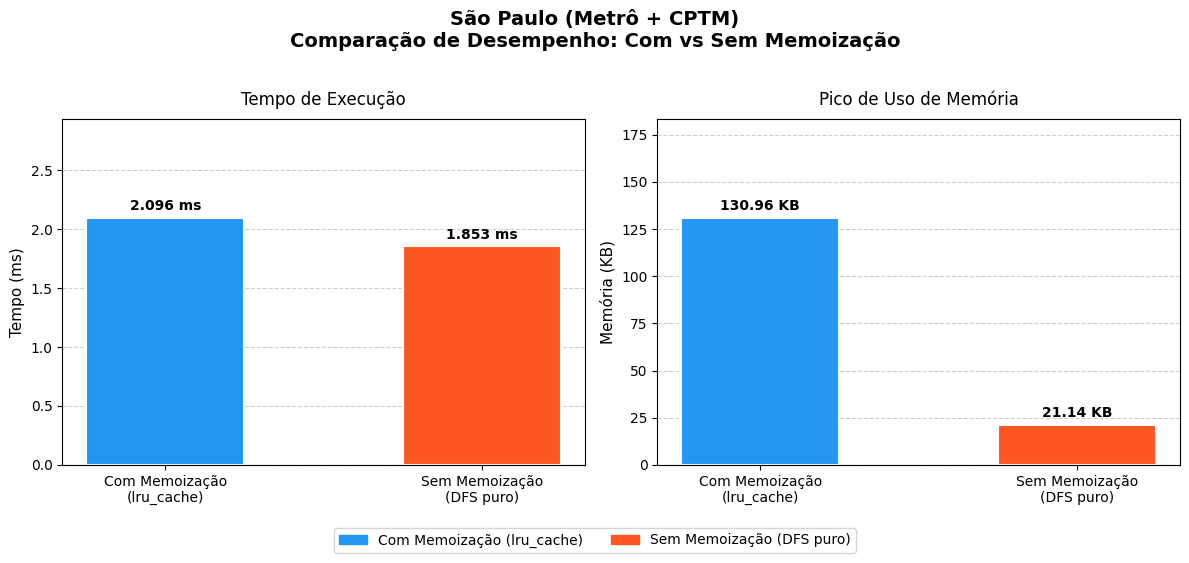

Gráfico salvo como desempenho_sp.png


In [10]:
# =============================================================================
# GRÁFICO COMPARATIVO — TEMPO DE EXECUÇÃO E USO DE MEMÓRIA
# =============================================================================
# Dois subgráficos lado a lado:
#   Esquerda: tempo de execução (ms) — com vs sem memoização
#   Direita : pico de memória (KB)   — com vs sem memoização
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("São Paulo (Metrô + CPTM)\nComparação de Desempenho: Com vs Sem Memoização",
             fontsize=14, fontweight="bold", y=1.02)

categorias = ["Com Memoização\n(lru_cache)", "Sem Memoização\n(DFS puro)"]
cores      = ["#2196F3", "#FF5722"]

# ── Subplot 1: Tempo de execução ──────────────────────────────────────────────
ax1 = axes[0]
barras1 = ax1.bar(categorias, [tempo_memo_ms, tempo_sem_memo_ms],
                  color=cores, width=0.5, edgecolor="white", linewidth=1.5)
ax1.set_title("Tempo de Execução", fontsize=12, pad=10)
ax1.set_ylabel("Tempo (ms)", fontsize=11)
ax1.set_ylim(0, max(tempo_memo_ms, tempo_sem_memo_ms) * 1.4)
ax1.yaxis.grid(True, linestyle="--", alpha=0.6)
ax1.set_axisbelow(True)

# Anotações com o valor em cima de cada barra
for barra, valor in zip(barras1, [tempo_memo_ms, tempo_sem_memo_ms]):
    ax1.text(barra.get_x() + barra.get_width() / 2,
             barra.get_height() + 0.02 * max(tempo_memo_ms, tempo_sem_memo_ms),
             f"{valor:.3f} ms", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Subplot 2: Memória ────────────────────────────────────────────────────────
ax2 = axes[1]
barras2 = ax2.bar(categorias, [mem_memo_kb, mem_sem_memo_kb],
                  color=cores, width=0.5, edgecolor="white", linewidth=1.5)
ax2.set_title("Pico de Uso de Memória", fontsize=12, pad=10)
ax2.set_ylabel("Memória (KB)", fontsize=11)
ax2.set_ylim(0, max(mem_memo_kb, mem_sem_memo_kb) * 1.4)
ax2.yaxis.grid(True, linestyle="--", alpha=0.6)
ax2.set_axisbelow(True)

for barra, valor in zip(barras2, [mem_memo_kb, mem_sem_memo_kb]):
    ax2.text(barra.get_x() + barra.get_width() / 2,
             barra.get_height() + 0.02 * max(mem_memo_kb, mem_sem_memo_kb),
             f"{valor:.2f} KB", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Legenda compartilhada
patch_memo    = mpatches.Patch(color="#2196F3", label="Com Memoização (lru_cache)")
patch_sem     = mpatches.Patch(color="#FF5722", label="Sem Memoização (DFS puro)")
fig.legend(handles=[patch_memo, patch_sem], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("desempenho_sp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo como desempenho_sp.png")

In [11]:
# =============================================================================
# CONCLUSÃO — SÃO PAULO
# =============================================================================
print("\n" + "=" * 60)
print("  CONCLUSÃO — SÃO PAULO (Metrô + CPTM)")
print("=" * 60)
print(f"""
Grafo modelado com 37 estações e 5 linhas (azul, verde, amarela, lilás,
esmeralda), cobrindo as principais integrações do sistema Metrô + CPTM.

MENOR CAMINHO (hora = {hora}h, fator = {fator_horario(hora)}×):
  Rota: {" -> ".join(caminho_min_memo)}
  Tempo total: {formatar_tempo(custo_min_memo)}
  O algoritmo optou pela Linha Amarela (Luz → Pinheiros) sempre que
  possível, pois seu peso 0,9 a torna mais eficiente que a Azul pura
  no trecho central.

MAIOR CAMINHO (hora = {hora}h):
  Tempo total: {formatar_tempo(custo_max)}
  {len(caminho_max)} estações percorridas — maximiza desvios e trocas de linha.

MEMOIZAÇÃO vs SEM MEMOIZAÇÃO:
  - Tempo com memo  : {tempo_memo_ms:.3f} ms
  - Tempo sem memo  : {tempo_sem_memo_ms:.3f} ms
  - Razão           : {tempo_memo_ms/tempo_sem_memo_ms:.2f}× {"mais lento (memo)" if tempo_memo_ms > tempo_sem_memo_ms else "mais rápido (memo)"}

  A versão com memoização foi {"mais lenta" if tempo_memo_ms > tempo_sem_memo_ms else "mais rápida"} neste grafo de {len(grafo)} nós.
  Isso ocorre porque o frozenset `visitados` na chave do cache cria
  estados quase sempre únicos (cada caminho percorrido = frozenset
  diferente), eliminando os cache hits. O overhead de hashing supera
  o ganho de cache em grafos pequenos.

  Em redes reais (90+ estações, São Paulo completo), a memoização
  se tornaria essencial para viabilizar a busca exaustiva.

COMPLEXIDADE:
  - Menor caminho (DFS): O(n!) sem memo | O(n×2^n) com memo
  - Maior caminho: O(n!) — NP-difícil, viável apenas para n pequeno
""")


  CONCLUSÃO — SÃO PAULO (Metrô + CPTM)

Grafo modelado com 37 estações e 5 linhas (azul, verde, amarela, lilás,
esmeralda), cobrindo as principais integrações do sistema Metrô + CPTM.

MENOR CAMINHO (hora = 18h, fator = 2.0×):
  Rota: Tucuruvi -> Parada Inglesa -> Jardim Sao Paulo -> Santana -> Carandiru -> Portuguesa-Tiete -> Armenia -> Tiradentes -> Luz -> Sao Bento -> Se -> Liberdade -> Sao Joaquim -> Vergueiro -> Paraiso -> Ana Rosa -> Vila Mariana -> Santa Cruz -> Santo Amaro -> Campo Limpo -> Capao Redondo
  Tempo total: 1h 42min
  O algoritmo optou pela Linha Amarela (Luz → Pinheiros) sempre que
  possível, pois seu peso 0,9 a torna mais eficiente que a Azul pura
  no trecho central.

MAIOR CAMINHO (hora = 18h):
  Tempo total: 1h 56min
  21 estações percorridas — maximiza desvios e trocas de linha.

MEMOIZAÇÃO vs SEM MEMOIZAÇÃO:
  - Tempo com memo  : 2.096 ms
  - Tempo sem memo  : 1.853 ms
  - Razão           : 1.13× mais lento (memo)

  A versão com memoização foi mais lenta n

In [12]:
# =============================================================================
# MAPA INTERATIVO — FOLIUM
# =============================================================================
# Gera um mapa HTML interativo sobreposto ao mapa real de São Paulo.
# Cores:
#   Verde (marcador)  — estação de origem
#   Vermelho (marcador) — estação de destino
#   Azul (marcadores) — demais estações
#   Verde (linha espessa) — menor caminho
#   Vermelho (linha)      — maior caminho
#   Cinza (linhas finas)  — todas as conexões do grafo
# =============================================================================

# Coordenadas geográficas aproximadas de cada estação (lat, lon)
coords = {
    "Tucuruvi":          (-23.480, -46.603),
    "Parada Inglesa":    (-23.487, -46.608),
    "Jardim Sao Paulo":  (-23.492, -46.614),
    "Santana":           (-23.500, -46.625),
    "Carandiru":         (-23.507, -46.623),
    "Portuguesa-Tiete":  (-23.516, -46.622),
    "Armenia":           (-23.525, -46.629),
    "Tiradentes":        (-23.531, -46.633),
    "Luz":               (-23.536, -46.633),
    "Sao Bento":         (-23.544, -46.634),
    "Se":                (-23.550, -46.633),
    "Liberdade":         (-23.556, -46.635),
    "Sao Joaquim":       (-23.561, -46.638),
    "Vergueiro":         (-23.568, -46.640),
    "Paraiso":           (-23.575, -46.640),
    "Ana Rosa":          (-23.582, -46.638),
    "Vila Mariana":      (-23.589, -46.634),
    "Santa Cruz":        (-23.600, -46.637),
    "Praca da Arvore":   (-23.610, -46.637),
    "Saude":             (-23.620, -46.636),
    "Sao Judas":         (-23.628, -46.635),
    "Conceicao":         (-23.635, -46.641),
    "Jabaquara":         (-23.646, -46.641),
    "Republica":         (-23.544, -46.642),
    "Paulista":          (-23.555, -46.662),
    "Pinheiros":         (-23.566, -46.702),
    "Vila Sonia":        (-23.588, -46.734),
    "Brigadeiro":        (-23.561, -46.655),
    "Trianon-Masp":      (-23.561, -46.659),
    "Consolacao":        (-23.557, -46.662),
    "Clinicas":          (-23.555, -46.673),
    "Sumare":            (-23.550, -46.680),
    "Vila Madalena":     (-23.546, -46.692),
    "Chacara Klabin":    (-23.592, -46.630),
    "Santo Amaro":       (-23.650, -46.710),
    "Campo Limpo":       (-23.650, -46.760),
    "Capao Redondo":     (-23.660, -46.780)
}

In [13]:
import folium

# Cria o mapa centrado em São Paulo com tiles neutros
mapa = folium.Map(location=[-23.55, -46.63], zoom_start=11, tiles="CartoDB positron")

In [14]:
# Adiciona marcador para cada estação
for estacao, (lat, lon) in coords.items():
    cor = "green" if estacao == origem else ("red" if estacao == destino else "blue")
    folium.Marker(
        [lat, lon],
        popup=estacao,
        icon=folium.Icon(color=cor)
    ).add_to(mapa)

In [15]:
# Desenha todas as arestas do grafo (cinza, peso 2)
arestas_desenhadas = set()
for orig in grafo:
    for aresta in grafo[orig]:
        dest  = aresta["destino"]
        chave = tuple(sorted([orig, dest]))
        if chave in arestas_desenhadas:
            continue
        arestas_desenhadas.add(chave)
        if orig in coords and dest in coords:
            folium.PolyLine(
                [coords[orig], coords[dest]],
                color="gray", weight=2, opacity=0.4
            ).add_to(mapa)

In [16]:
# Destaca o menor caminho (verde espesso)
folium.PolyLine(
    [coords[e] for e in caminho_min_memo if e in coords],
    color="green", weight=6, opacity=0.9
).add_to(mapa)

# Destaca o maior caminho (vermelho)
folium.PolyLine(
    [coords[e] for e in caminho_max if e in coords],
    color="red", weight=4, opacity=0.8
).add_to(mapa)

In [17]:
mapa.save("metro_sp.html")
print("Mapa salvo como metro_sp.html")

Mapa salvo como metro_sp.html
